In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('./data/processed_newsgroups.csv')

In [63]:
df['processed_text'] = df['processed_text'].fillna('')
print(f"Total documents loaded: {len(df)}")

Total documents loaded: 19955


In [64]:
# mapping the 20 granular categories into the 6 parent categories
category_mapping = {
    # computers
    'comp.graphics': 'comp',
    'comp.os.ms-windows.misc': 'comp',
    'comp.sys.ibm.pc.hardware': 'comp',
    'comp.sys.mac.hardware': 'comp',
    'comp.windows.x': 'comp',
    
    # recreation
    'rec.autos': 'rec',
    'rec.motorcycles': 'rec',
    'rec.sport.baseball': 'rec',
    'rec.sport.hockey': 'rec',
    
    # science
    'sci.crypt': 'sci',
    'sci.electronics': 'sci',
    'sci.med': 'sci',
    'sci.space': 'sci',
    
    # miscellaneous
    'misc.forsale': 'misc',
    
    # politics
    'talk.politics.misc': 'politics',
    'talk.politics.guns': 'politics',
    'talk.politics.mideast': 'politics',
    
    # religion
    'talk.religion.misc': 'religion',
    'alt.atheism': 'religion',
    'soc.religion.christian': 'religion'
}

In [65]:
df['parent_label'] = df['label'].map(category_mapping) # create the new target column

print("\nClass Distribution for 6 Macro Categories:")
print(df['parent_label'].value_counts())


Class Distribution for 6 Macro Categories:
parent_label
comp        4980
sci         3995
rec         3993
politics    3000
religion    2996
misc         991
Name: count, dtype: int64


In [66]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=5)

In [67]:
print("\nBuilding TF-IDF feature matrix...")
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
y = df['parent_label']


Building TF-IDF feature matrix...


In [68]:
print(f"TF-IDF Matrix Shape: {X_tfidf.shape} (Documents, Unique Words)\n")

TF-IDF Matrix Shape: (19955, 24195) (Documents, Unique Words)



In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [70]:
print("Training Multinomial Naive Bayes classifier...")
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

Training Multinomial Naive Bayes classifier...


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [71]:
y_pred = nb_classifier.predict(X_test)

In [72]:
print("\nCLASSIFICATION REPORT - For 6 CATEGORIES")
print(classification_report(y_test, y_pred))


CLASSIFICATION REPORT - For 6 CATEGORIES
              precision    recall  f1-score   support

        comp       0.78      0.98      0.87       996
        misc       0.88      0.11      0.19       198
    politics       0.89      0.88      0.89       600
         rec       0.91      0.95      0.93       799
    religion       0.94      0.87      0.91       599
         sci       0.88      0.82      0.85       799

    accuracy                           0.87      3991
   macro avg       0.88      0.77      0.77      3991
weighted avg       0.87      0.87      0.85      3991



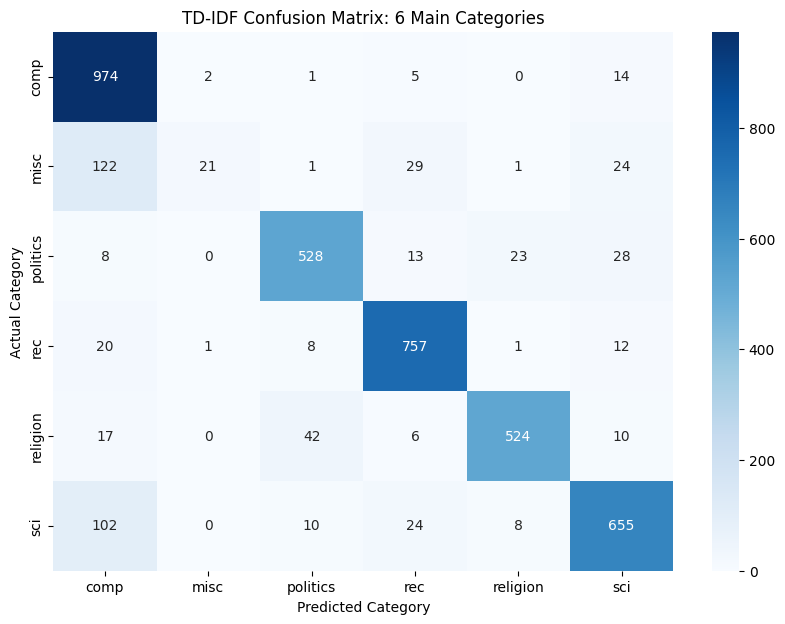

In [73]:
cm = confusion_matrix(y_test, y_pred, labels=nb_classifier.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb_classifier.classes_, yticklabels=nb_classifier.classes_)

plt.title('TD-IDF Confusion Matrix: 6 Main Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

In [74]:
print("Starting Hierarchical Classification Pipeline...\n")

Starting Hierarchical Classification Pipeline...



In [75]:
y_parent = df['parent_label']
y_child = df['label'] # original 20 sub topics labels

In [76]:
X_train, X_test, y_train_parent, y_test_parent, y_train_child, y_test_child = train_test_split(
    X_tfidf, y_parent, y_child, test_size=0.2, random_state=42, stratify=y_child
)

In [77]:
print("Training Level 1 - Main Parent Classifier...")
parent_classifier = MultinomialNB()
parent_classifier.fit(X_train, y_train_parent)

Training Level 1 - Main Parent Classifier...


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [78]:
print("Training Level 2 - Child Category Classifiers...")
child_classifiers = {}

for parent_category in y_parent.unique():
    mask = (y_train_parent == parent_category).values
    X_train_specific = X_train[mask]
    y_train_specific = y_train_child[mask]
    
    specific_classifier = MultinomialNB()
    specific_classifier.fit(X_train_specific, y_train_specific)
    
    child_classifiers[parent_category] = specific_classifier
    print(f"{parent_category} Classifier trained successfully!")

Training Level 2 - Child Category Classifiers...
politics Classifier trained successfully!
rec Classifier trained successfully!
comp Classifier trained successfully!
religion Classifier trained successfully!
sci Classifier trained successfully!
misc Classifier trained successfully!


In [79]:
print("\nMaking Hierarchical Predictions on Test Data")

final_predictions = []

parent_predictions = parent_classifier.predict(X_test)

for i in range(X_test.shape[0]):
    predicted_parent = parent_predictions[i]
    expert_model = child_classifiers[predicted_parent]
    
    final_guess = expert_model.predict(X_test[i])
    final_predictions.append(final_guess[0])


Making Hierarchical Predictions on Test Data


In [80]:
print("\nHIERARCHICAL CLASSIFICATION REPORT - 20 CATEGORIES")
print(f"Overall Accuracy: {accuracy_score(y_test_child, final_predictions):.4f}\n")
print(classification_report(y_test_child, final_predictions))


HIERARCHICAL CLASSIFICATION REPORT - 20 CATEGORIES
Overall Accuracy: 0.7632

                          precision    recall  f1-score   support

             alt.atheism       0.75      0.72      0.74       200
           comp.graphics       0.59      0.78      0.67       199
 comp.os.ms-windows.misc       0.68      0.68      0.68       198
comp.sys.ibm.pc.hardware       0.51      0.80      0.62       199
   comp.sys.mac.hardware       0.61      0.76      0.68       199
          comp.windows.x       0.77      0.85      0.81       200
            misc.forsale       0.93      0.07      0.12       198
               rec.autos       0.80      0.84      0.82       200
         rec.motorcycles       0.89      0.93      0.91       199
      rec.sport.baseball       0.89      0.92      0.90       200
        rec.sport.hockey       0.91      0.98      0.95       200
               sci.crypt       0.87      0.85      0.86       200
         sci.electronics       0.84      0.60      0.70       2